In [0]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
)


import matplotlib.pyplot as plt
import seaborn as sns


from pyspark.sql import SparkSession

# 1. Load data from gold table

In [0]:
df = spark.table("workspace.premier_league_gold.training_features").toPandas()

print("=== Dataset overview ===")
print(f"Total records: {len(df)}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Shape: {df.shape}\n")

display(df.head())

=== Dataset overview ===
Total records: 80
Seasons: ['2021-22', '2022-23', '2023-24', '2024-25']
Shape: (80, 24)



season,team,target_points,target_position,prev_points,prev_position,prev_position_vs_avg,prev_goal_difference,prev_wins,prev_draws,prev_losses,prev_goals_for,prev_goals_against,prev_home_wins,prev_away_wins,prev_home_goals_for,prev_away_goals_for,prev_points_per_game,prev_win_pct,prev_goals_per_game,prev_goals_conceded_per_game,prev_home_advantage,prev_position_category,is_promoted
2021-22,Manchester City,93,1,86,1,-9.5,51,27,5,6,83,32,13,14,43,40,2.263157894736842,0.7105263157894737,2.1842105263157894,0.8421052631578947,0.07894736842105263,top4,0
2021-22,Liverpool,92,2,69,3,-7.5,26,20,9,9,68,42,10,10,29,39,1.8157894736842106,0.5263157894736842,1.7894736842105263,1.105263157894737,-0.2631578947368421,top4,0
2021-22,Chelsea,74,3,67,4,-6.5,22,19,10,9,58,36,9,10,31,27,1.763157894736842,0.5,1.5263157894736843,0.9473684210526315,0.10526315789473684,top4,0
2021-22,Tottenham,71,4,62,7,-3.5,23,18,8,12,68,45,10,8,35,33,1.631578947368421,0.47368421052631576,1.7894736842105263,1.1842105263157894,0.05263157894736842,europa,0
2021-22,Arsenal,69,5,61,8,-2.5,16,18,7,13,55,39,8,10,24,31,1.605263157894737,0.47368421052631576,1.4473684210526316,1.0263157894736843,-0.18421052631578946,mid_table,0


# 2. Train / test split by season


In [0]:
train_seasons = ["2021-22", "2022-23", "2023-24"]
test_season = "2024-25"

train_df = df[df["season"].isin(train_seasons)].copy()
test_df = df[df["season"] == test_season].copy()

print("=== Train / test split ===")
print(f"Training set: {len(train_df)} rows ({len(train_df) / len(df) * 100:.1f}%)")
print(f"  Seasons: {train_seasons}")
print(f"Test set: {len(test_df)} rows ({len(test_df) / len(df) * 100:.1f}%)")
print(f"  Season: {test_season}\n")

=== Train / test split ===
Training set: 60 rows (75.0%)
  Seasons: ['2021-22', '2022-23', '2023-24']
Test set: 20 rows (25.0%)
  Season: 2024-25



# 3. Prepare features and target

In [0]:
feature_cols = [
    "prev_points",
    "prev_position",
    "prev_position_vs_avg",
    "prev_goal_difference",
    "prev_wins",
    "prev_draws",
    "prev_losses",
    "prev_points_per_game",
    "prev_win_pct",
    "prev_goals_per_game",
    "prev_goals_conceded_per_game",
    "prev_home_advantage",
    "prev_home_wins",
    "prev_away_wins",
    "is_promoted",
]

# Map position category to numeric
category_mapping = {
    "top4": 1,
    "europa": 2,
    "mid_table": 3,
    "relegation_battle": 4,
}

train_df["prev_position_category_numeric"] = train_df["prev_position_category"].map(
    category_mapping
)
test_df["prev_position_category_numeric"] = test_df["prev_position_category"].map(
    category_mapping
)

feature_cols.append("prev_position_category_numeric")

X_train = train_df[feature_cols]
y_train = train_df["target_points"]

X_test = test_df[feature_cols]
y_test = test_df["target_points"]

print("=== Features ===")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Number of features: {len(feature_cols)}")
print(feature_cols, "\n")


=== Features ===
Training features shape: (60, 16)
Test features shape: (20, 16)
Number of features: 16
['prev_points', 'prev_position', 'prev_position_vs_avg', 'prev_goal_difference', 'prev_wins', 'prev_draws', 'prev_losses', 'prev_points_per_game', 'prev_win_pct', 'prev_goals_per_game', 'prev_goals_conceded_per_game', 'prev_home_advantage', 'prev_home_wins', 'prev_away_wins', 'is_promoted', 'prev_position_category_numeric'] 



# 4. Baseline model (last season's points)

In [0]:
baseline_predictions = test_df["prev_points"].values

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("=== Baseline (last season's points) ===")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²:   {baseline_r2:.3f}\n")


=== Baseline (last season's points) ===
MAE:  13.20
RMSE: 16.36
R²:   0.183



# 5. Train Random Forest model

In [0]:
params = {
    "n_estimators": 200,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1,
}

print("Training Random Forest model...")
rf_model = RandomForestRegressor(**params)
rf_model.fit(X_train, y_train)

train_predictions = rf_model.predict(X_train)
test_predictions = rf_model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
train_r2 = r2_score(y_train, train_predictions)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("=== Random Forest performance ===")
print(f"Train MAE:  {train_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R²:   {train_r2:.3f}")
print(f"\nTest MAE:  {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²:   {test_r2:.3f}")
print(f"\nMAE improvement over baseline: {baseline_mae - test_mae:.2f}\n")

Training Random Forest model...
=== Random Forest performance ===
Train MAE:  6.43
Train RMSE: 7.83
Train R²:   0.826

Test MAE:  9.81
Test RMSE: 12.50
Test R²:   0.524

MAE improvement over baseline: 3.39



# 6. "Coefficients": correlations + feature importance

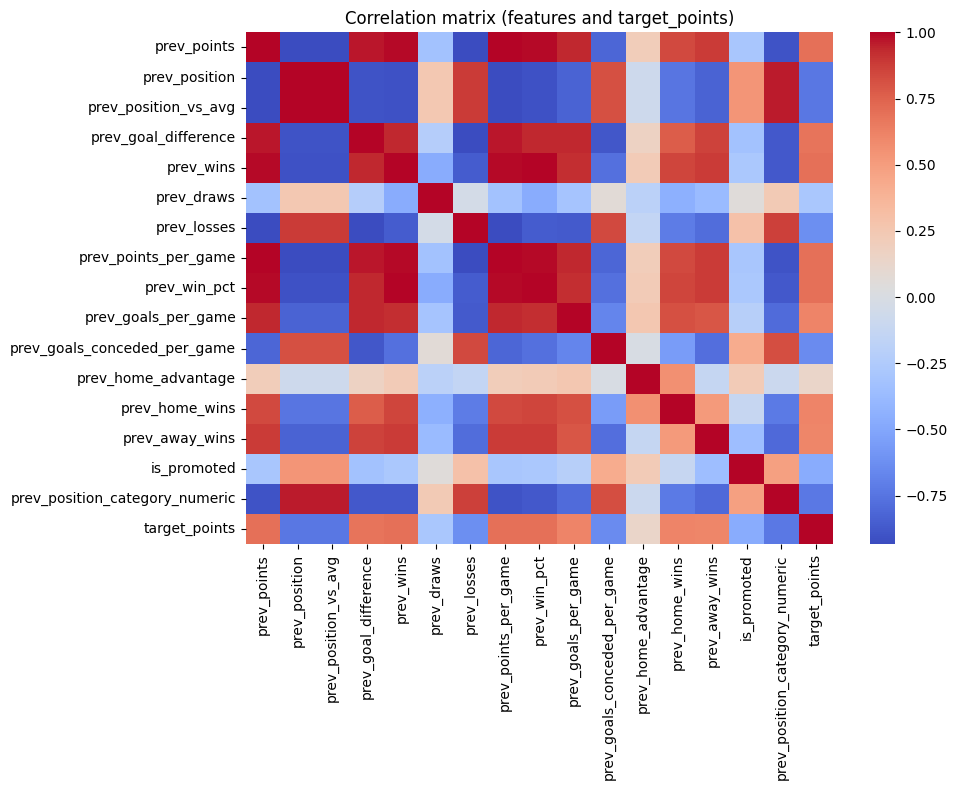

=== Feature importance (Random Forest) ===


feature,importance
prev_home_wins,0.11886279500454319
prev_points_per_game,0.11637904557162736
prev_position_vs_avg,0.10010680337920572
prev_position,0.09461871461735766
prev_goals_conceded_per_game,0.08704629933755623
prev_points,0.08370076849623649
prev_goal_difference,0.069210867412119
prev_away_wins,0.061057221603058355
prev_home_advantage,0.06033038866541968
prev_wins,0.044222449034639705


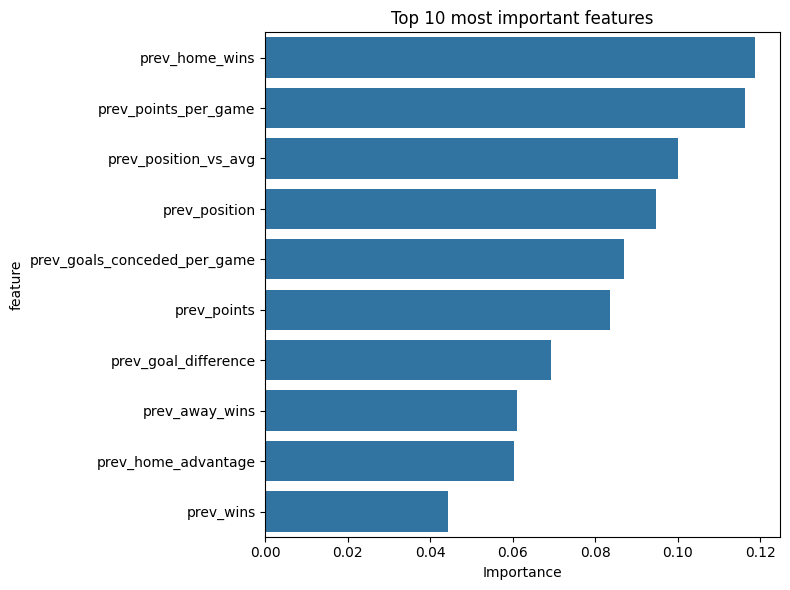

In [0]:
# Correlation matrix (features + target)
corr_cols = feature_cols + ["target_points"]
corr_df = train_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="coolwarm", annot=False)
plt.title("Correlation matrix (features and target_points)")
plt.tight_layout()
plt.show()

# Feature importance from Random Forest
feature_importance = pd.DataFrame(
    {"feature": feature_cols, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)

print("=== Feature importance (Random Forest) ===")
display(feature_importance)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature",
    orient="h",
)
plt.title("Top 10 most important features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# 7. Build results table for test season

In [0]:
results_df = test_df[
    ["team", "season", "target_points", "target_position", "prev_points", "prev_position"]
].copy()

results_df["predicted_points"] = test_predictions
results_df["baseline_points"] = baseline_predictions
results_df["prediction_error"] = results_df["predicted_points"] - results_df["target_points"]
results_df["baseline_error"] = results_df["baseline_points"] - results_df["target_points"]

results_df = results_df.sort_values("target_points", ascending=False)

print("=== 2024-25 predictions (sorted by actual points) ===")
display(results_df)


=== 2024-25 predictions (sorted by actual points) ===


team,season,target_points,target_position,prev_points,prev_position,predicted_points,baseline_points,prediction_error,baseline_error
Liverpool,2024-25,84,1,82,3,75.33085714285713,82,-8.669142857142873,-2
Arsenal,2024-25,74,2,89,2,78.11309325396823,89,4.113093253968231,15
Manchester City,2024-25,71,3,91,1,82.10388492063493,91,11.103884920634925,20
Chelsea,2024-25,69,4,63,6,63.78152069567861,63,-5.2184793043213915,-6
Newcastle United,2024-25,66,5,60,7,66.2380113161692,60,0.23801131616920657,-6
Aston Villa,2024-25,66,6,68,4,71.98391576479077,68,5.9839157647907655,2
Nottingham Forest,2024-25,65,7,36,17,34.65270787545787,36,-30.34729212454213,-29
Brighton & Hove Albion,2024-25,61,8,48,11,48.41674463840253,48,-12.583255361597473,-13
Bournemouth,2024-25,56,9,48,13,47.43889415555207,48,-8.56110584444793,-8
Brentford,2024-25,56,10,39,16,40.52235417360418,39,-15.477645826395822,-17


# 8. Regression plots: predictions vs actual and residuals

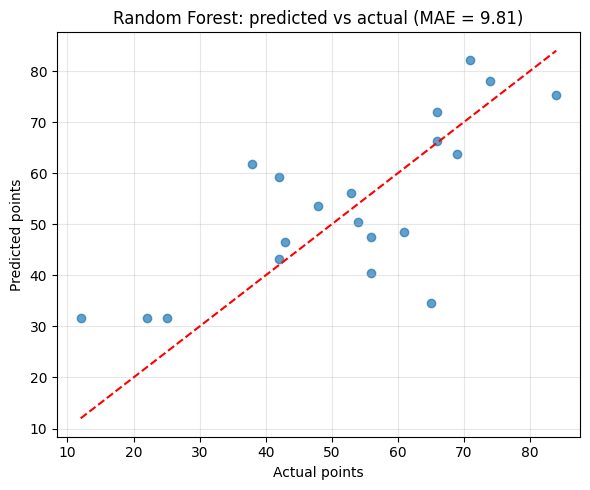

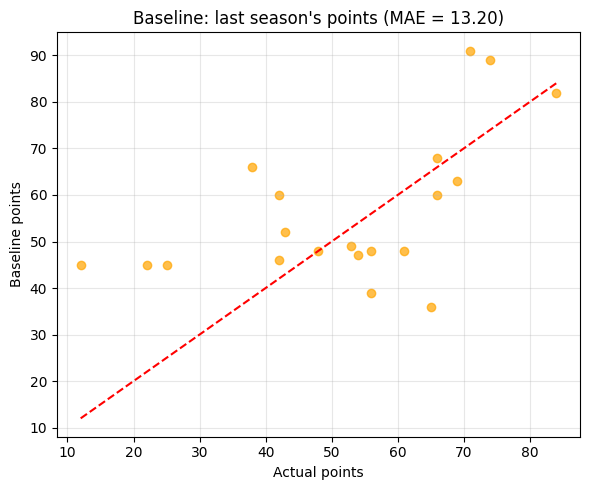

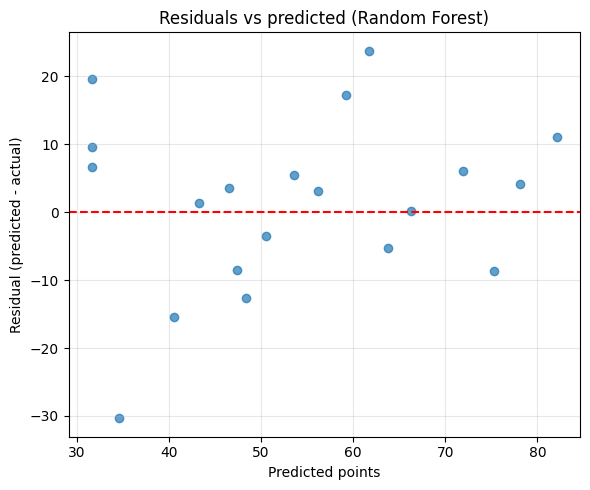

In [0]:
# Scatter: model vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_predictions, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red",
)
plt.xlabel("Actual points")
plt.ylabel("Predicted points")
plt.title(f"Random Forest: predicted vs actual (MAE = {test_mae:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter: baseline vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_test, baseline_predictions, alpha=0.7, color="orange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red",
)
plt.xlabel("Actual points")
plt.ylabel("Baseline points")
plt.title(f"Baseline: last season's points (MAE = {baseline_mae:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot for model
residuals = test_predictions - y_test.values

plt.figure(figsize=(6, 5))
plt.scatter(test_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted points")
plt.ylabel("Residual (predicted - actual)")
plt.title("Residuals vs predicted (Random Forest)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 9. Error analysis by team

In [0]:
results_df["abs_error_rf"] = np.abs(results_df["prediction_error"])
results_df["abs_error_baseline"] = np.abs(results_df["baseline_error"])

print("=== Error by team (sorted by Random Forest error) ===")
display(
    results_df[["team", "abs_error_rf", "abs_error_baseline"]].sort_values(
        "abs_error_rf"
    )
)

worse_than_baseline = results_df[results_df["abs_error_rf"] > results_df["abs_error_baseline"]]
better_than_baseline = results_df[results_df["abs_error_rf"] < results_df["abs_error_baseline"]]

print(f"\nTeams where model did worse than baseline: {len(worse_than_baseline)}")
if len(worse_than_baseline) > 0:
    display(
        worse_than_baseline[
            ["team", "target_points", "predicted_points", "baseline_points"]
        ]
    )

print(f"\nTeams where model did better than baseline: {len(better_than_baseline)}")
if len(better_than_baseline) > 0:
    display(
        better_than_baseline[
            ["team", "target_points", "predicted_points", "baseline_points"]
        ]
    )

=== Error by team (sorted by Random Forest error) ===


team,abs_error_rf,abs_error_baseline
Newcastle United,0.23801131616920657,6
Wolves,1.2861915109743833,4
Crystal Palace,3.159470390720429,4
Fulham,3.4810853174603267,7
West Ham United,3.5329874095203095,9
Arsenal,4.113093253968231,15
Chelsea,5.2184793043213915,6
Everton,5.539396284271291,0
Aston Villa,5.9839157647907655,2
Leicester,6.649586497931875,20



Teams where model did worse than baseline: 5


team,target_points,predicted_points,baseline_points
Liverpool,84,75.33085714285713,82
Aston Villa,66,71.98391576479077,68
Nottingham Forest,65,34.65270787545787,36
Bournemouth,56,47.43889415555207,48
Everton,48,53.53939628427129,48



Teams where model did better than baseline: 15


team,target_points,predicted_points,baseline_points
Arsenal,74,78.11309325396823,89
Manchester City,71,82.10388492063493,91
Chelsea,69,63.78152069567861,63
Newcastle United,66,66.2380113161692,60
Brighton & Hove Albion,61,48.41674463840253,48
Brentford,56,40.52235417360418,39
Fulham,54,50.51891468253967,47
Crystal Palace,53,56.15947039072043,49
West Ham United,43,46.53298740952031,52
Manchester United,42,59.24803914141414,60


# 10. Position predictions + confusion matrix

=== Predicted final table (2024-25, by predicted points) ===


predicted_position,team,predicted_points,target_points,target_position
1,Manchester City,82.10388492063493,71,3
2,Arsenal,78.11309325396823,74,2
3,Liverpool,75.33085714285713,84,1
4,Aston Villa,71.98391576479077,66,6
5,Newcastle United,66.2380113161692,66,5
6,Chelsea,63.78152069567861,69,4
7,Tottenham,61.75907611832612,38,17
8,Manchester United,59.24803914141414,42,15
9,Crystal Palace,56.15947039072043,53,12
10,Everton,53.53939628427129,48,13



=== Position prediction accuracy ===
Mean absolute position error: 2.80
Median position error: 2


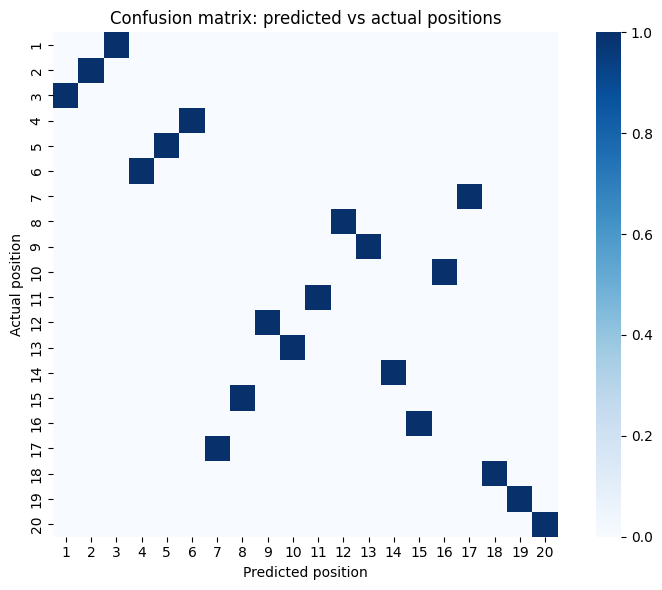


Top 4 prediction: 3/4 correct
  Predicted: {'Liverpool', 'Manchester City', 'Aston Villa', 'Arsenal'}
  Actual:    {'Liverpool', 'Manchester City', 'Chelsea', 'Arsenal'}

Bottom 3 prediction: 3/3 correct
  Predicted: {'Southampton', 'Leicester', 'Ipswich'}
  Actual:    {'Southampton', 'Leicester', 'Ipswich'}


In [0]:
# Rank by predicted points
results_df = results_df.sort_values("predicted_points", ascending=False).reset_index(
    drop=True
)
results_df["predicted_position"] = range(1, len(results_df) + 1)

# Position error
results_df["position_error"] = np.abs(
    results_df["predicted_position"] - results_df["target_position"]
)

print("=== Predicted final table (2024-25, by predicted points) ===")
display(
    results_df[
        ["predicted_position", "team", "predicted_points", "target_points", "target_position"]
    ]
)

print("\n=== Position prediction accuracy ===")
print(f"Mean absolute position error: {results_df['position_error'].mean():.2f}")
print(f"Median position error: {results_df['position_error'].median():.0f}")

# Confusion matrix for positions (predicted vs actual)
y_true_pos = results_df["target_position"].values
y_pred_pos = results_df["predicted_position"].values

cm = confusion_matrix(y_true_pos, y_pred_pos, labels=range(1, len(results_df) + 1))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True,
    square=True,
    xticklabels=range(1, len(results_df) + 1),
    yticklabels=range(1, len(results_df) + 1),
)
plt.xlabel("Predicted position")
plt.ylabel("Actual position")
plt.title("Confusion matrix: predicted vs actual positions")
plt.tight_layout()
plt.show()

# Top 4 and bottom 3 checks
predicted_top4 = set(results_df.head(4)["team"])
actual_top4 = set(results_df.sort_values("target_position").head(4)["team"])
top4_correct = len(predicted_top4.intersection(actual_top4))

predicted_bottom3 = set(results_df.tail(3)["team"])
actual_bottom3 = set(
    results_df.sort_values("target_position", ascending=False).head(3)["team"]
)
bottom3_correct = len(predicted_bottom3.intersection(actual_bottom3))

print(f"\nTop 4 prediction: {top4_correct}/4 correct")
print(f"  Predicted: {predicted_top4}")
print(f"  Actual:    {actual_top4}")

print(f"\nBottom 3 prediction: {bottom3_correct}/3 correct")
print(f"  Predicted: {predicted_bottom3}")
print(f"  Actual:    {actual_bottom3}")


# 11. Save predictions back to gold

In [0]:
results_spark = spark.createDataFrame(results_df)
results_spark.write.format("delta").mode("overwrite").saveAsTable(
    "workspace.premier_league_gold.model_predictions_2024_25"
)

print("\nPredictions saved to: workspace.premier_league_gold.model_predictions_2024_25")


Predictions saved to: workspace.premier_league_gold.model_predictions_2024_25


In [0]:
# full table of model_predictions_2024_25
display(results_spark)

team,season,target_points,target_position,prev_points,prev_position,predicted_points,baseline_points,prediction_error,baseline_error,abs_error_rf,abs_error_baseline,predicted_position,position_error
Manchester City,2024-25,71,3,91,1,82.10388492063493,91,11.103884920634925,20,11.103884920634925,20,1,2
Arsenal,2024-25,74,2,89,2,78.11309325396823,89,4.113093253968231,15,4.113093253968231,15,2,0
Liverpool,2024-25,84,1,82,3,75.33085714285713,82,-8.669142857142873,-2,8.669142857142873,2,3,2
Aston Villa,2024-25,66,6,68,4,71.98391576479077,68,5.9839157647907655,2,5.9839157647907655,2,4,2
Newcastle United,2024-25,66,5,60,7,66.2380113161692,60,0.23801131616920657,-6,0.23801131616920657,6,5,0
Chelsea,2024-25,69,4,63,6,63.78152069567861,63,-5.2184793043213915,-6,5.2184793043213915,6,6,2
Tottenham,2024-25,38,17,66,5,61.75907611832612,66,23.75907611832612,28,23.75907611832612,28,7,10
Manchester United,2024-25,42,15,60,8,59.24803914141414,60,17.24803914141414,18,17.24803914141414,18,8,7
Crystal Palace,2024-25,53,12,49,10,56.15947039072043,49,3.159470390720429,-4,3.159470390720429,4,9,3
Everton,2024-25,48,13,48,12,53.53939628427129,48,5.539396284271291,0,5.539396284271291,0,10,3
